In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# define a function
def approx_ln(x, n=10):
    if x>0:
        if n<=0:
            n = 1
        # even if we will set incorrect 'n', we must make at least one iteration step
        a = np.longdouble((x+1)/2)
        g = np.longdouble(np.sqrt(x,dtype=np.longdouble))
        while n>0:
            a = (a+g)/2
            g = np.sqrt(a*g,dtype=np.longdouble)
            n = n-1
        return np.longdouble((x-1)/a)
    else:
        return np.nan

In [3]:
# basic functionality check
print(approx_ln(1.71),approx_ln(1.71,25),np.log(1.71,dtype=np.longdouble))
print(approx_ln(-1.71),approx_ln(-1.71,25),np.log(-1.71,dtype=np.longdouble))

0.53649335824266562115 0.53649337051456844245 0.536493370514568454
nan nan nan


/tmp/ipykernel_507856/1224564655.py:3: RuntimeWarning: invalid value encountered in log
  print(approx_ln(-1.71),approx_ln(-1.71,25),np.log(-1.71,dtype=np.longdouble))


In [4]:
def plot_iteration(xscope,series, title, format="-", start=0):
    plt.figure(figsize=(14, 12))
    plt.suptitle(title, fontsize=12, fontweight='bold')
    plt.plot(xscope[start:], series[start:], "r"+format)
    plt.xlabel("Iteration")
    plt.ylabel("Value")
    plt.grid(True)

def plot_iteration2(xscope,series1,series2, title, format="-", start=0):
    plt.figure(figsize=(14, 12))
    plt.suptitle(title, fontsize=12, fontweight='bold')
    plt.plot(xscope[start:], series1[start:], "r"+format)
    plt.plot(xscope[start:], series2[start:], "b"+format)
    plt.xlabel("Iteration")
    plt.ylabel("Value")
    plt.grid(True)

In [5]:
# evaluate data, Task 2
Ncount = 50
x_val = 1.71
nr = np.zeros(Ncount,dtype=np.longdouble)
ln = np.zeros(Ncount,dtype=np.longdouble)
ln_a = np.zeros(Ncount,dtype=np.longdouble)
diff = np.zeros(Ncount,dtype=np.longdouble)
y = np.log(x_val,dtype=np.longdouble)
for i in range(1,Ncount+1,1):
    nr[i-1] = i
    ln[i-1] = y
    ln_a[i-1] = approx_ln(x_val,i)
    diff[i-1] = y-ln_a[i-1]

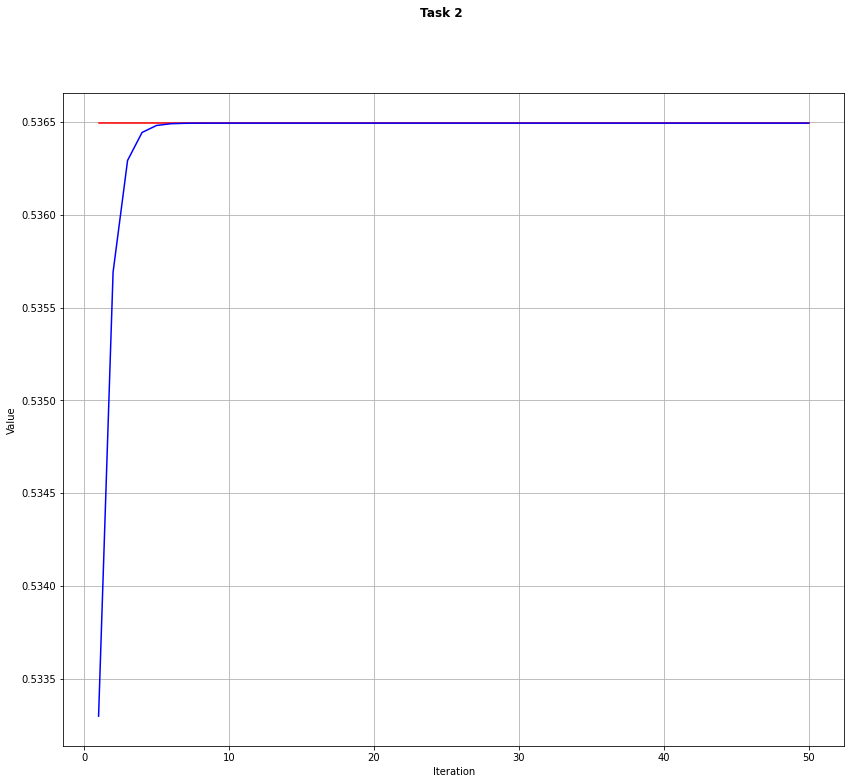

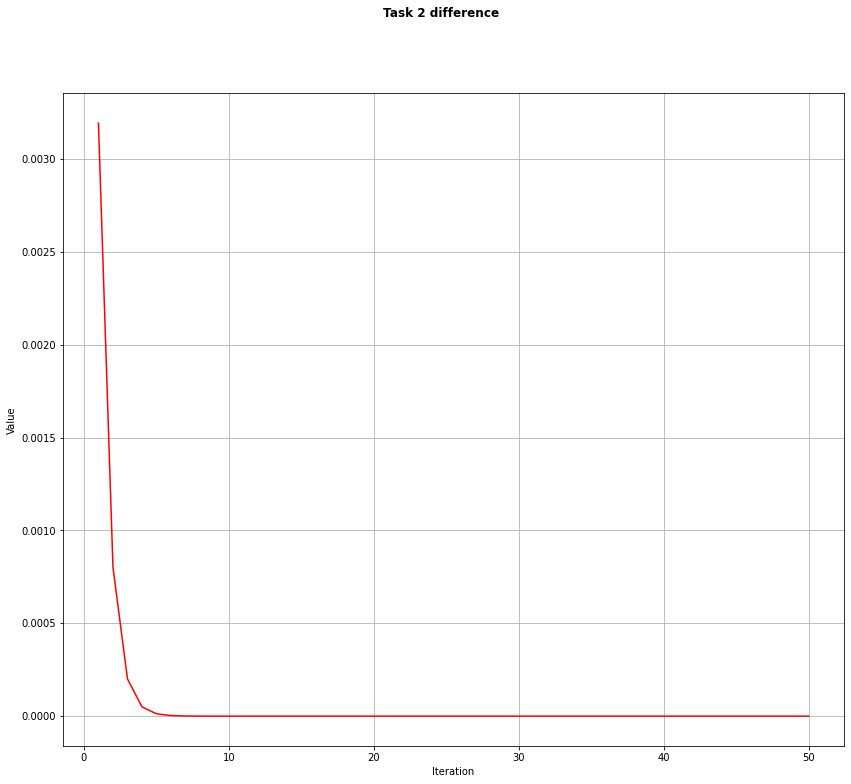

In [6]:
plot_iteration2(nr,ln,ln_a,"Task 2")
plot_iteration(nr,diff,"Task 2 difference")

In [45]:
# evaluate data, Task 3
Ncount = 50
x_val = 1.41
nr = np.zeros(Ncount,dtype=np.longdouble)
ln_a = np.zeros(Ncount,dtype=np.longdouble)
y = np.log(x_val,dtype=np.longdouble)
for i in range(1,Ncount+1,1):
    nr[i-1] = i
    ln_a[i-1] = np.abs(y-approx_ln(x_val,i),dtype=np.longdouble)

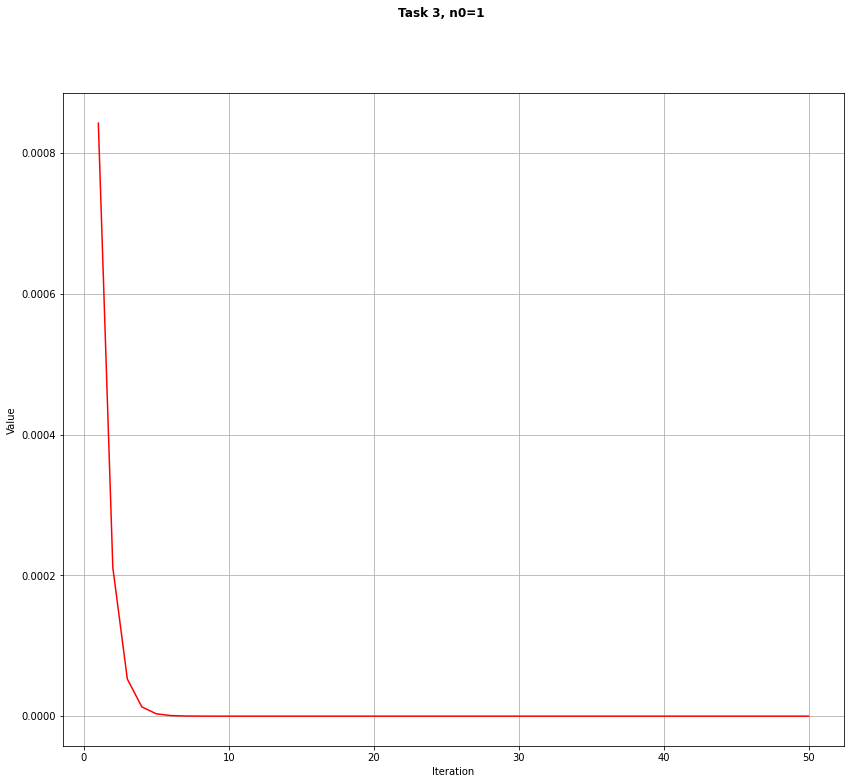

In [46]:
plot_iteration(nr,ln_a,"Task 3, n0=1")

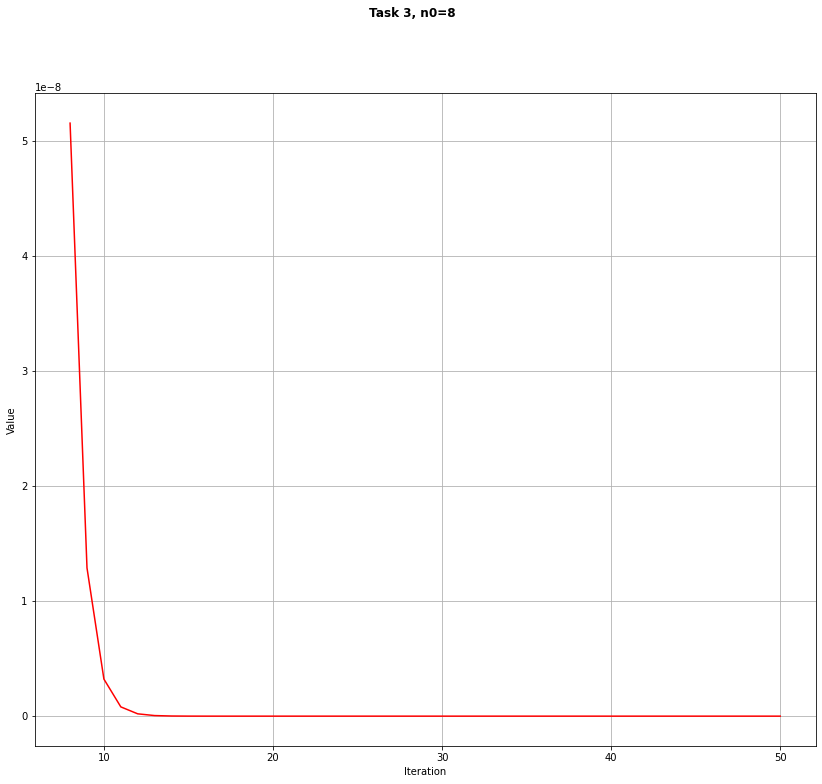

In [49]:
plot_iteration(nr,ln_a,"Task 3, n0=8",start=8-1)

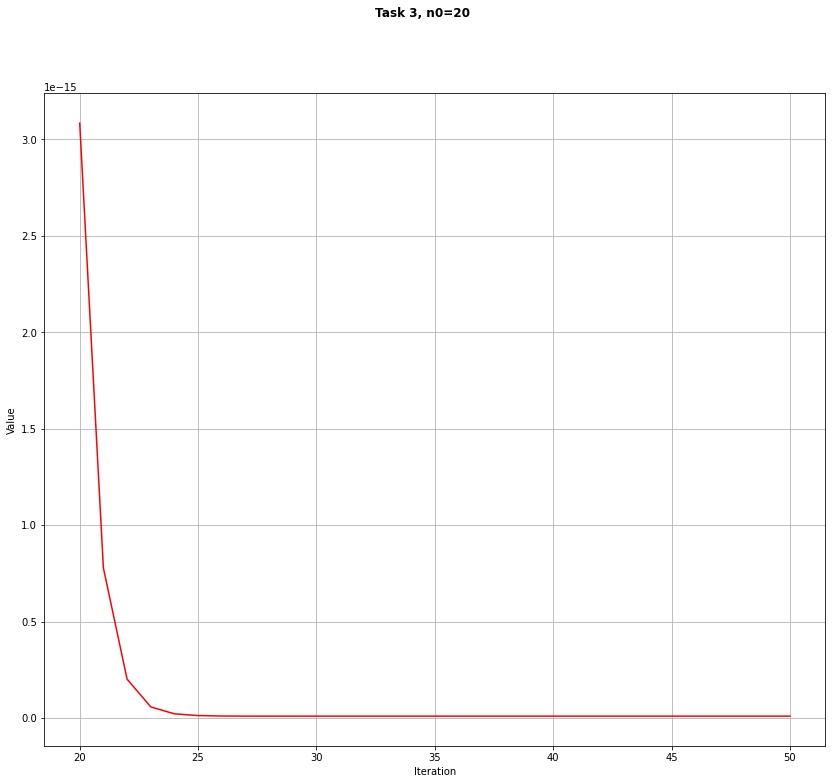

In [50]:
plot_iteration(nr,ln_a,"Task 3, n0=20",start=20-1)

In [81]:
# define an accelerated convergence function, dumb implementation, used original article description
# for verification
def fast_approx_ln(x, n=10):
    if x>0:
        if n<=0:
            n = 1
        # even if we will set incorrect 'n', we must make at least one iteration step
        N = n
        a = np.longdouble((x+1)/2)
        g = np.longdouble(np.sqrt(x,dtype=np.longdouble))
        d = np.zeros(shape=(n+1,n+1),dtype=np.longdouble) # n+1 values, in python 0..n 
        d[0,0] = a
        while n>0:
            a = np.longdouble((a+g)/2)
            g = np.sqrt(a*g,dtype=np.longdouble)
            n = n-1
            d[0,N-n] = a
        dv = np.longdouble(0.25) # 4^{-1}, we can't be limited by a fixed number of bits in integer representation
        for k in range(1,N+1,1): # 1..n
            for i in range(1,N+1,1): # 1..n
                d[k,i] = np.longdouble(d[k-1,i]-np.longdouble(dv*d[k-1,i-1]))/np.longdouble(1-dv)
            dv = np.longdouble(dv/4) # 4^{-k} for next iteration
        return np.longdouble((x-1)/d[N,N])
    else:
        return np.nan

In [82]:
# to validate and estimate results
print(approx_ln(1.71,15),fast_approx_ln(1.71,15),np.log(1.71,dtype=np.longdouble))

0.53649337050258417357 0.53649337051456845405 0.536493370514568454


In [94]:
xvals = np.linspace(1e-8,20,500) # 500 points from 0+ to 20 in array
yvals = np.array(list(map(lambda y: np.log(y,dtype=np.longdouble), xvals))) #evaluate f for each point in xvals
yvals2 = np.array(list(map(lambda y: fast_approx_ln(y,2), xvals))) #evaluate f for each point in xvals
yvals3 = np.array(list(map(lambda y: fast_approx_ln(y,3), xvals))) #evaluate f for each point in xvals 
yvals4 = np.array(list(map(lambda y: fast_approx_ln(y,4), xvals))) #evaluate f for each point in xvals 
yvals5 = np.array(list(map(lambda y: fast_approx_ln(y,5), xvals))) #evaluate f for each point in xvals 

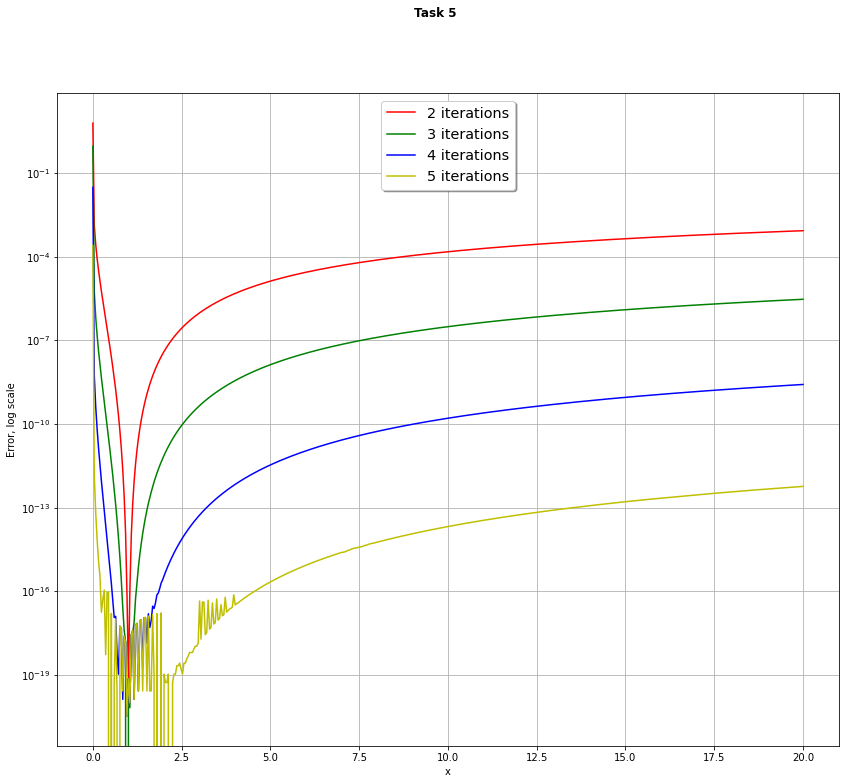

In [97]:
plt.figure(figsize=(14, 12))
plt.suptitle("Task 5", fontsize=12, fontweight='bold')
plt.yscale("log")
plt.plot(xvals, np.abs(yvals-yvals2), "r-",label="2 iterations")
plt.plot(xvals, np.abs(yvals-yvals3), "g-",label="3 iterations")
plt.plot(xvals, np.abs(yvals-yvals4), "b-",label="4 iterations")
plt.plot(xvals, np.abs(yvals-yvals5), "y-",label="5 iterations")
plt.xlabel("x")
plt.ylabel("Error, log scale")
plt.legend(loc='upper center', shadow=True, fontsize='x-large')
plt.grid(True)